<a href="https://colab.research.google.com/github/mrabinayaa/DAAexps/blob/main/exp2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

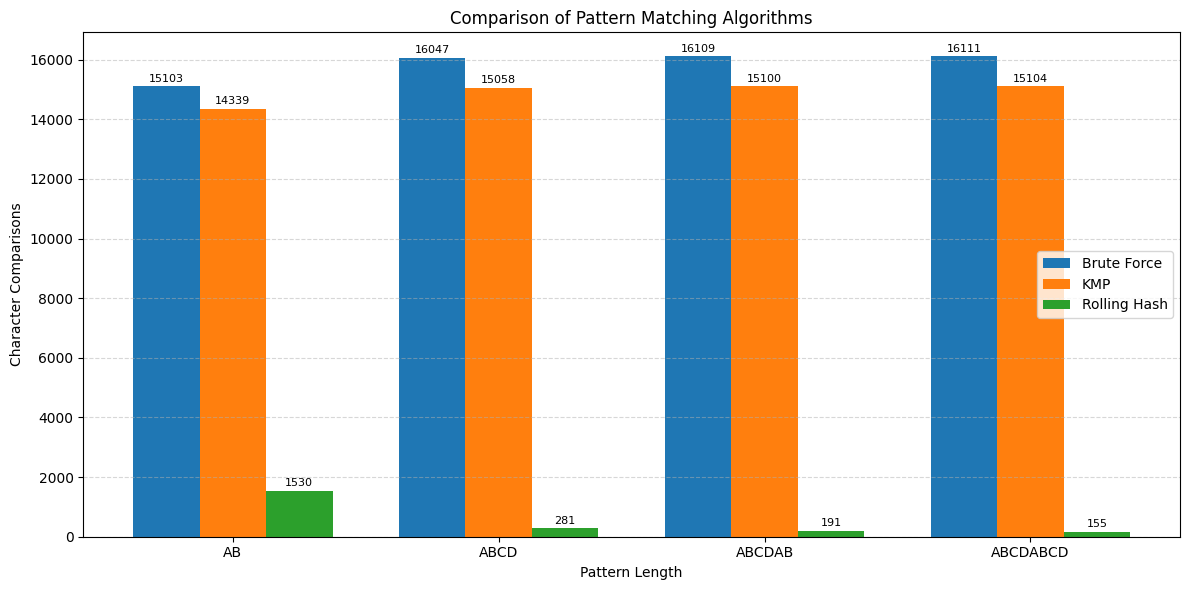

In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

# -------------------- Search Algorithms --------------------

def brute_force(text, pat):
    text_len = len(text)
    pat_len = len(pat)
    comparisons = 0

    for start in range(text_len - pat_len + 1):
        for pos in range(pat_len):
            comparisons += 1
            if text[start + pos] != pat[pos]:
                break

    return comparisons


def build_lps(pat):
    lps = [0] * len(pat)
    prefix = 0
    idx = 1

    while idx < len(pat):
        if pat[idx] == pat[prefix]:
            prefix += 1
            lps[idx] = prefix
            idx += 1
        elif prefix != 0:
            prefix = lps[prefix - 1]
        else:
            lps[idx] = 0
            idx += 1

    return lps


def kmp_match(text, pat):
    lps = build_lps(pat)

    i = j = 0
    comparisons = 0

    while i < len(text):
        comparisons += 1

        if text[i] == pat[j]:
            i += 1
            j += 1

            if j == len(pat):
                j = lps[j - 1]

        elif j != 0:
            j = lps[j - 1]
        else:
            i += 1

    return comparisons


def rolling_hash_search(text, pat, prime=101):
    alphabet = 256
    n = len(text)
    m = len(pat)

    factor = pow(alphabet, m - 1, prime)

    pattern_hash = 0
    window_hash = 0
    comparisons = 0

    for i in range(m):
        pattern_hash = (alphabet * pattern_hash + ord(pat[i])) % prime
        window_hash = (alphabet * window_hash + ord(text[i])) % prime

    for i in range(n - m + 1):

        if pattern_hash == window_hash:
            for j in range(m):
                comparisons += 1
                if text[i + j] != pat[j]:
                    break

        if i < n - m:
            window_hash = (
                alphabet * (window_hash - ord(text[i]) * factor)
                + ord(text[i + m])
            ) % prime

            if window_hash < 0:
                window_hash += prime

    return comparisons


# -------------------- Benchmark --------------------

text = ''.join(random.choices("ABCD", k=12000))

test_patterns = [
    "AB",
    "ABCD",
    "ABCDAB",
    "ABCDABCD"
]

comparison_data = {
    "Brute Force": [],
    "KMP": [],
    "Rolling Hash": []
}

for pattern in test_patterns:
    comparison_data["Brute Force"].append(brute_force(text, pattern))
    comparison_data["KMP"].append(kmp_match(text, pattern))
    comparison_data["Rolling Hash"].append(
        rolling_hash_search(text, pattern)
    )


# -------------------- Visualization --------------------

positions = np.arange(len(test_patterns))
bar_width = 0.25

plt.figure(figsize=(12,6))

plt.bar(
    positions - bar_width,
    comparison_data["Brute Force"],
    width=bar_width,
    label="Brute Force"
)

plt.bar(
    positions,
    comparison_data["KMP"],
    width=bar_width,
    label="KMP"
)

plt.bar(
    positions + bar_width,
    comparison_data["Rolling Hash"],
    width=bar_width,
    label="Rolling Hash"
)

# Value Labels
for offset, key in zip(
    [-bar_width, 0, bar_width],
    comparison_data.keys()
):
    for x, y in zip(positions + offset, comparison_data[key]):
        plt.text(
            x,
            y + max(comparison_data["Brute Force"]) * 0.01,
            str(y),
            ha="center",
            fontsize=8
        )

plt.xticks(positions, test_patterns)

plt.title("Comparison of Pattern Matching Algorithms")
plt.xlabel("Pattern Length")
plt.ylabel("Character Comparisons")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.legend()

plt.tight_layout()
plt.show()